In [8]:
# Data Loading & Preprocessing
import pandas as pd
import numpy as np

# Load the dataset
file_path = 'Master_DDoS_Dataset.csv'
print(f"Loading dataset from {file_path}...")
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")

df.columns = df.columns.str.strip()

# Handle Infinity, Missing and NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"Dataset shape after cleaning: {df.shape}")

print("Dataset columns:")
print(df.columns)

target_column = 'Label'



Loading dataset from Master_DDoS_Dataset.csv...


C:\Users\User\AppData\Local\Temp\ipykernel_7280\1062310583.py:8: DtypeWarning: Columns (0: SimillarHTTP) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset shape: (360000, 88)
Dataset shape after cleaning: (347189, 88)
Dataset columns:
Index(['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd 

In [9]:
# drop useless columns
columns_to_drop = ['Unnamed: 0', 'Flow ID', ' Source IP', ' Destination IP', ' Timestamp', 'SimillarHTTP']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
print(f"Dataset shape after dropping columns: {df_cleaned.shape}")
print("Remaining columns:")
print(df_cleaned.columns)

Dataset shape after dropping columns: (347189, 85)
Remaining columns:
Index(['Source IP', 'Source Port', 'Destination IP', 'Destination Port',
       'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Pa

In [10]:
# Separate features
X = df_cleaned.drop(columns=[target_column]) # easy way to separate features from target
y = df_cleaned[target_column]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

dashboard_features = [
    'Flow Bytes/s', ' Flow Packets/s', ' Packet Length Mean', 
    ' Flow Duration', ' SYN Flag Count', ' ACK Flag Count'
]

Features (X) shape: (347189, 84)
Target (y) shape: (347189,)


In [11]:
# Label Encoding & Stratified Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Get purely numeric data
X = X.select_dtypes(include=[np.number])

# Label Encoding for Target Variable
print("Encoding target variable...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Classes mapping: {classes_mapping}")


Encoding target variable...
Classes mapping: {'BENIGN': np.int64(0), 'DrDoS_DNS': np.int64(1), 'DrDoS_LDAP': np.int64(2), 'DrDoS_MSSQL': np.int64(3), 'DrDoS_NTP': np.int64(4), 'DrDoS_NetBIOS': np.int64(5), 'DrDoS_SNMP': np.int64(6), 'DrDoS_SSDP': np.int64(7), 'DrDoS_UDP': np.int64(8), 'LDAP': np.int64(9), 'MSSQL': np.int64(10), 'NetBIOS': np.int64(11), 'Portmap': np.int64(12), 'Syn': np.int64(13), 'TFTP': np.int64(14), 'UDP': np.int64(15), 'UDP-lag': np.int64(16), 'WebDDoS': np.int64(17)}


In [12]:
# Stratified Train-Test Split (80% Train, 20% Test)
print("Performing stratified train-test split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")

Performing stratified train-test split...
Training Data: 277751 rows
Testing Data: 69438 rows


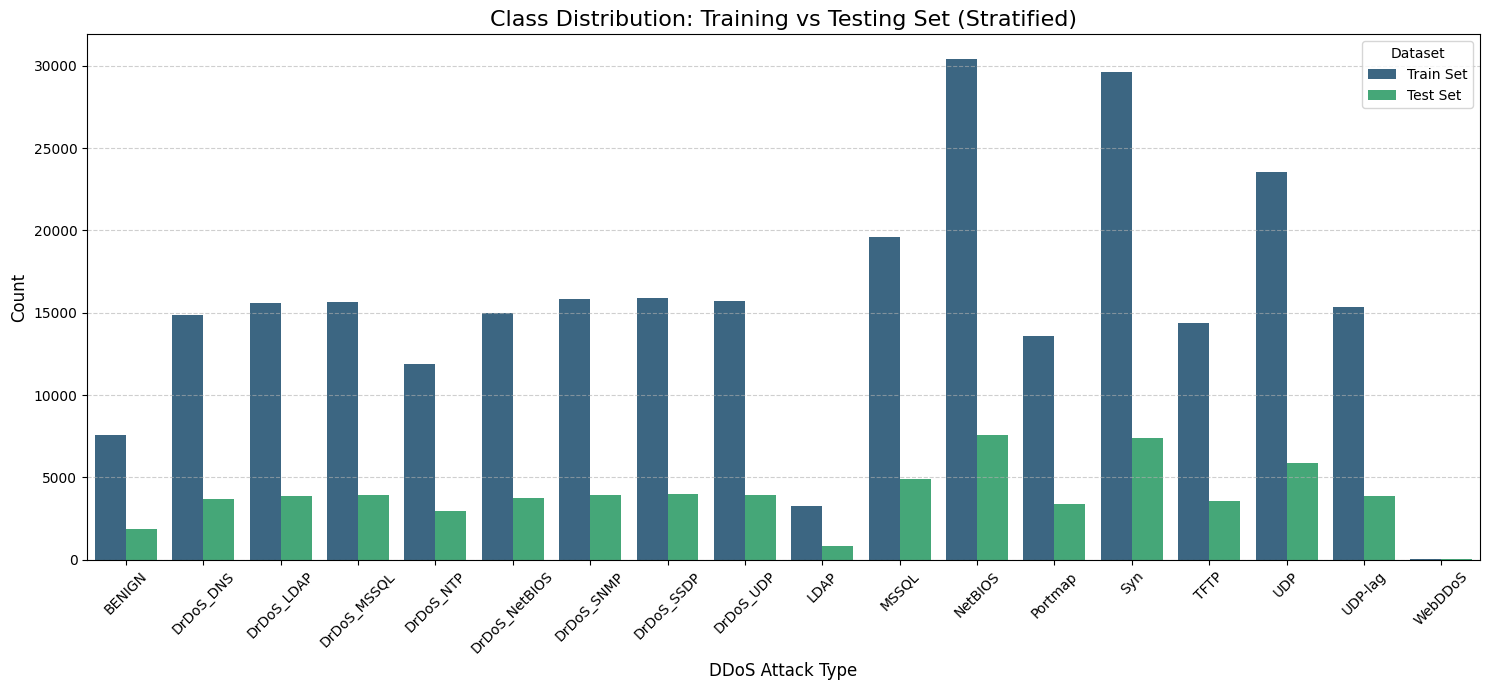

In [13]:
# Verify data splitiing from visually
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric labels to Attack names
train_labels = le.inverse_transform(y_train)
test_labels = le.inverse_transform(y_test)

train_df = pd.DataFrame(train_labels, columns=['Attack Type'])
train_df['Dataset'] = 'Train Set'

test_df = pd.DataFrame(test_labels, columns=['Attack Type'])
test_df['Dataset'] = 'Test Set'

# combine
df_split_viz = pd.concat([train_df, test_df])

plt.figure(figsize=(15, 7))
sns.countplot(data=df_split_viz, x='Attack Type', hue='Dataset', palette='viridis', 
              order=sorted(df_split_viz['Attack Type'].unique()))

plt.title('Class Distribution: Training vs Testing Set (Stratified)', fontsize=16)
plt.xlabel('DDoS Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('data_split_distribution.png')

In [14]:
# Replace duplicate column names with unique names
print("Cleaning and merging duplicate labels...")

label_mapping = {
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_UDP': 'UDP',
    'Syn': 'SYN'
}
df_cleaned['Label'] = df_cleaned['Label'].replace(label_mapping)

print("new classess after merging duplicates:")
print(df_cleaned['Label'].unique())

Cleaning and merging duplicate labels...
new classess after merging duplicates:
<ArrowStringArray>
[     'MSSQL',       'LDAP',     'BENIGN',        'UDP',    'NetBIOS',
        'SYN',    'Portmap',    'UDP-lag',    'WebDDoS',  'DrDoS_DNS',
 'DrDoS_SNMP',       'TFTP', 'DrDoS_SSDP',  'DrDoS_NTP']
Length: 14, dtype: str


In [15]:
# Apply SMOTE Oversampling
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("Re-seperating features and target after merging...")
X = df_cleaned.drop(columns=['Label']).select_dtypes(include=[np.number]) # only numeric features
y = df_cleaned['Label']

print("Re-encoding target labels after merging...")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Classes mapping after merging: {classes_mapping}")

print("Performing Stratified Split on cleaned data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training Data (Before SMOTE): {X_train.shape[0]} rows")

print("Applying SMOTE to balance the training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Training Data (After SMOTE): {X_train_smote.shape[0]} rows")

Re-seperating features and target after merging...
Re-encoding target labels after merging...
Classes mapping after merging: {'BENIGN': np.int64(0), 'DrDoS_DNS': np.int64(1), 'DrDoS_NTP': np.int64(2), 'DrDoS_SNMP': np.int64(3), 'DrDoS_SSDP': np.int64(4), 'LDAP': np.int64(5), 'MSSQL': np.int64(6), 'NetBIOS': np.int64(7), 'Portmap': np.int64(8), 'SYN': np.int64(9), 'TFTP': np.int64(10), 'UDP': np.int64(11), 'UDP-lag': np.int64(12), 'WebDDoS': np.int64(13)}
Performing Stratified Split on cleaned data...
Training Data (Before SMOTE): 277751 rows
Applying SMOTE to balance the training data...
Training Data (After SMOTE): 635110 rows


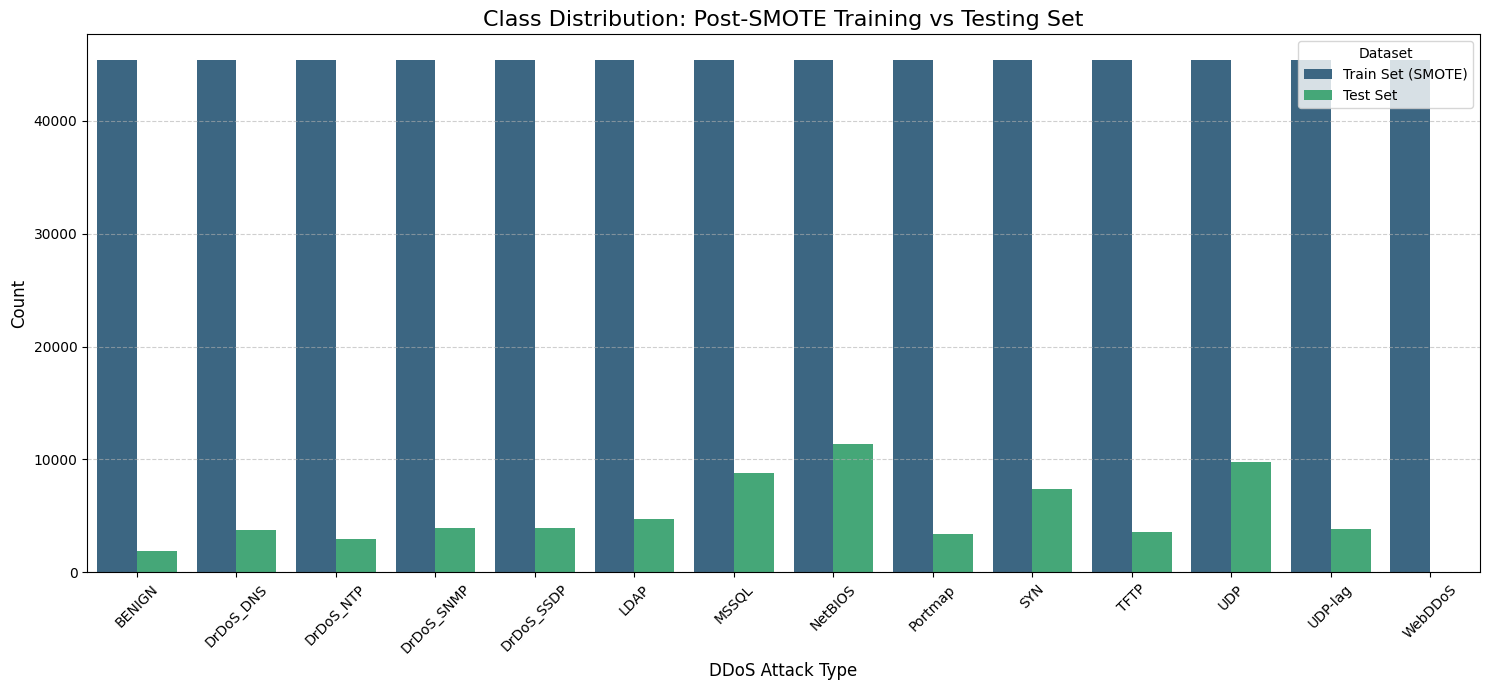

In [16]:
# Verify data splitting visually after merging duplicates and applying SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# මෙතන y_train වෙනුවට y_train_smote යොදා ඇත
train_labels = le.inverse_transform(y_train_smote) 
test_labels = le.inverse_transform(y_test)

train_df = pd.DataFrame(train_labels, columns=['Attack Type'])
train_df['Dataset'] = 'Train Set (SMOTE)'

test_df = pd.DataFrame(test_labels, columns=['Attack Type'])
test_df['Dataset'] = 'Test Set'

# combine
df_split_viz = pd.concat([train_df, test_df])

plt.figure(figsize=(15, 7))
sns.countplot(data=df_split_viz, x='Attack Type', hue='Dataset', palette='viridis', 
              order=sorted(df_split_viz['Attack Type'].unique()))

plt.title('Class Distribution: Post-SMOTE Training vs Testing Set', fontsize=16)
plt.xlabel('DDoS Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot
plt.savefig('split_distribution_smote.png')

In [17]:
# GPU-Accelerated XGBoost Training & Evaluation
import xgboost as xgb
import time
from sklearn.metrics import classification_report, confusion_matrix

# Model Configuration
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    tree_method='hist',
    device = 'cuda',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
# Model Training
print(f"Training started on {X_train_smote.shape[0]} rows using GPU.")
start_time = time.time()

xgb_model.fit(X_train_smote, y_train_smote)

end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds.")



Training started on 635110 rows using GPU.
Training completed in 13.51 seconds.


In [22]:
# Check Model Evaluation using Test Data
print("\nEvaluating the model on Test Set...")

y_pred = xgb_model.predict(X_test)

# Print Classification Report
print("\n" + "="*50)
print(" CLASSIFICATION REPORT ")
print("="*50)
print(classification_report(y_test, y_pred, target_names=le.classes_))


Evaluating the model on Test Set...

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      1887
   DrDoS_DNS       0.89      0.86      0.88      3716
   DrDoS_NTP       0.97      0.97      0.97      2975
  DrDoS_SNMP       0.82      0.65      0.72      3954
  DrDoS_SSDP       0.72      0.76      0.74      3976
        LDAP       0.70      0.86      0.77      4708
       MSSQL       0.91      0.78      0.84      8819
     NetBIOS       0.85      0.70      0.77     11342
     Portmap       0.55      0.91      0.69      3397
         SYN       0.99      0.86      0.92      7412
        TFTP       0.77      0.98      0.86      3587
         UDP       0.78      0.80      0.79      9813
     UDP-lag       0.50      0.53      0.51      3842
     WebDDoS       0.04      0.30      0.07        10

    accuracy                           0.80     69438
   macro avg       0.75      0.78      0.75     69438
weighted avg      

In [23]:
import pandas as pd

print("Loading raw Master CSV to investigate...")
# Use low_memory=False to prevent the DtypeWarning while loading the CSV
df_raw = pd.read_csv('Master_DDoS_Dataset.csv', low_memory=False)

# Remove spaces from column names
df_raw.columns = df_raw.columns.str.strip()

print("\n" + "="*40)
print(" 🔍 ORIGINAL DATA COUNTS (BEFORE CLEANING)")
print("="*40)
print(df_raw['Label'].value_counts())
print("="*40)

Loading raw Master CSV to investigate...

 🔍 ORIGINAL DATA COUNTS (BEFORE CLEANING)
Label
Syn              39997
NetBIOS          39966
UDP              29580
MSSQL            25575
DrDoS_LDAP       19998
TFTP             19997
DrDoS_UDP        19994
DrDoS_SNMP       19983
DrDoS_SSDP       19947
DrDoS_NetBIOS    19926
DrDoS_MSSQL      19755
DrDoS_DNS        19338
UDP-lag          19299
Portmap          18066
DrDoS_NTP        14974
BENIGN            9497
LDAP              4057
WebDDoS             51
Name: count, dtype: int64


In [20]:
# import joblib

# print("Saving the models for the Dashboard...")
# xgb_model.save_model("xgboost_ddos_classifier.json")
# joblib.dump(le, "label_encoder.joblib")

# print("✅ Models saved successfully! Ready for Deployment.")

# Regression Model

In [25]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("Engineering Threat Severity Score...")

# Give score using Attack type
base_severity = {
    'BENIGN': 0,
    'WebDDoS': 30,
    'Portmap': 40,
    'UDP-lag': 50,
    'DrDoS_DNS': 60,
    'DrDoS_NTP': 60,
    'DrDoS_SNMP': 60,
    'DrDoS_SSDP': 60,
    'LDAP': 70,
    'MSSQL': 70,
    'NetBIOS': 70,
    'TFTP': 70,
    'UDP': 80,
    'SYN': 80
}

# create Base Score column
df_cleaned['Base_Score'] = df_cleaned['Label'].map(base_severity)

# Calculate Network Traffic Volume
# Get total weight using Bytes and Packets
traffic_volume = df_cleaned['Flow Bytes/s'].fillna(0) + df_cleaned['Flow Packets/s'].fillna(0)

# Scale it to a value between 0 and 20 (maximum traffic gets 20 points)
scaler = MinMaxScaler(feature_range=(0, 20))
traffic_factor = scaler.fit_transform(traffic_volume.values.reshape(-1, 1))

# Build the Total Severity Score (Base Score + Traffic Factor)
df_cleaned['Severity_Score'] = np.clip(df_cleaned['Base_Score'] + traffic_factor.flatten(), 0, 100)

print("Severity Score calculation complete!")
print(df_cleaned[['Label', 'Base_Score', 'Severity_Score']].sample(10))

Engineering Threat Severity Score...
Severity Score calculation complete!
             Label  Base_Score  Severity_Score
269957         SYN          80       80.013578
359494   DrDoS_NTP          60       60.040989
248968  DrDoS_SSDP          60       60.000092
43101      NetBIOS          70       73.122878
301996       MSSQL          70       75.716225
190085   DrDoS_DNS          60       79.674134
68962        MSSQL          70       72.294637
10374        MSSQL          70       77.603530
70551          UDP          80       80.325866
248895  DrDoS_SSDP          60       60.000087


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("\nPreparing data for Regression Model...")

# Split features (X) and target (y)
# Keep only numeric features after dropping Label, Base_Score, Severity_Score
X_reg = df_cleaned.drop(columns=['Label', 'Base_Score', 'Severity_Score']).select_dtypes(include=[np.number])
y_reg = df_cleaned['Severity_Score']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print("Initializing XGBoost Regressor on GPU...")
# Use XGBRegressor for regression
xgb_regressor = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    device='cuda',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

print(f"Training Regressor on {X_train_r.shape[0]} rows...")
xgb_regressor.fit(X_train_r, y_train_r)

print("✅ Regression Model Training Completed!")

# Evaluation
y_pred_r = xgb_regressor.predict(X_test_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

print("\n" + "="*40)
print(" REGRESSION MODEL PERFORMANCE ")
print("="*40)
print(f"Mean Absolute Error (MAE): {mae:.2f} %")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} %")



Preparing data for Regression Model...
Initializing XGBoost Regressor on GPU...
Training Regressor on 277751 rows...
✅ Regression Model Training Completed!

 REGRESSION MODEL PERFORMANCE 
Mean Absolute Error (MAE): 4.18 %
Root Mean Squared Error (RMSE): 6.96 %


In [28]:
import joblib

print("\nSaving regression model and scaler...")

# Save the trained XGBoost regressor
xgb_regressor.save_model("xgboost_severity_regressor.json")

# Save the traffic scaler (needed in the dashboard to scale new traffic input)
joblib.dump(scaler, "traffic_scaler.joblib")

print("✅ All regression assets saved successfully!")


Saving regression model and scaler...
✅ All regression assets saved successfully!
